# **Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification.**

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI and ML/Week4/Copy of devnagari digit.zip'
extract_to = '/content/drive/MyDrive/AI and ML/Week4/devnagari_digits'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("ZIP file extracted to:", extract_to)

ZIP file extracted to: /content/drive/MyDrive/AI and ML/Week4/devnagari_digits


# Task 1: Data Preparation:

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


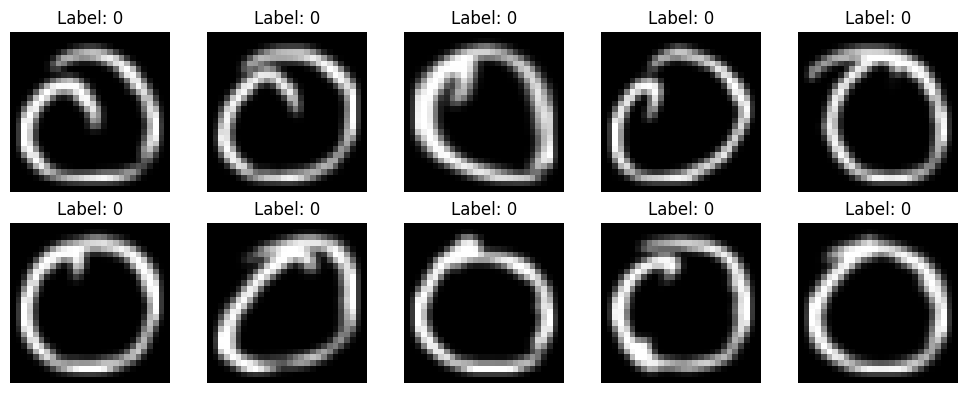

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image  # PIL for image loading

# STEP 1: LOAD DATASET FROM DRIVE
train_dir = '/content/drive/MyDrive/AI and ML/Week4/devnagari_digits/DevanagariHandwrittenDigitDataset/Train'
test_dir  = '/content/drive/MyDrive/AI and ML/Week4/devnagari_digits/DevanagariHandwrittenDigitDataset/Test'

# Define consistent image size (28x28 as required)
img_height, img_width = 28, 28


# STEP 2: LOAD IMAGES USING PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    # Get class names (each folder represents a digit class)
    class_names = sorted(os.listdir(folder))

    # Create mapping from class name -> numeric label
    class_map = {name: i for i, name in enumerate(class_names)}

    # Loop through each class folder
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        # Loop through each image file in the folder
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")

            # Resize image to 28x28 (consistent shape)
            img = img.resize((img_width, img_height))

            # Convert image to NumPy array and normalize (0–1)
            img = np.array(img) / 255.0

            # Store image and label
            images.append(img)
            labels.append(label)

    # Convert lists to NumPy arrays
    return np.array(images), np.array(labels)


# STEP 3: LOAD TRAIN & TEST DATA

x_train, y_train = load_images_from_folder(train_dir)

x_test, y_test = load_images_from_folder(test_dir)


# STEP 4: RESHAPE DATA FOR CNN

# Add channel dimension (needed for CNN input)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)


# STEP 5: ONE-HOT ENCODE LABELS
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


# STEP 6: DATASET SUMMARY
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")


# STEP 7: VISUALIZE SAMPLE IMAGES
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model

In [5]:
# MODEL ARCHITECTURE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10
input_shape = (28, 28, 1)

# Create Sequential Model
model = keras.Sequential([

    # Input Layer
    keras.layers.Input(shape=input_shape),

    # Flatten Layer (convert 2D image to 1D vector)
    keras.layers.Flatten(),

    # Hidden Layers
    keras.layers.Dense(64, activation='sigmoid'),   # 1st hidden layer
    keras.layers.Dense(128, activation='sigmoid'),  # 2nd hidden layer
    keras.layers.Dense(256, activation='sigmoid'),  # 3rd hidden layer

    # Output Layer (10 classes)
    keras.layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

In [6]:
# MODEL COMPILATION

model.compile(
    optimizer='adam',  # Optimizer for updating weights
    loss='categorical_crossentropy',  # Used because labels are one-hot encoded
    metrics=['accuracy']  # Evaluate model performance using accuracy
)

# Task 4: Train the Model

In [7]:
# MODEL TRAINING

# Training parameters
batch_size = 128
epochs = 20

# Callbacks: save best model & prevent overfitting
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,  # 20% data for validation
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4737 - loss: 1.6284 - val_accuracy: 0.0000e+00 - val_loss: 7.3829
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8551 - loss: 0.4856 - val_accuracy: 0.0000e+00 - val_loss: 8.7396
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9304 - loss: 0.2573 - val_accuracy: 0.0000e+00 - val_loss: 9.5228
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9474 - loss: 0.1836 - val_accuracy: 0.0000e+00 - val_loss: 9.9205
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9600 - loss: 0.1447 - val_accuracy: 0.0000e+00 - val_loss: 10.2496


# Task 5: Evaluate the Model

In [8]:
# MODEL EVALUATION

# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

# Display results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6180 - loss: 2.0974
Test Loss: 2.0974
Test Accuracy: 61.80%


# Task 6: Save and Load the Model

In [9]:
# Save the model in .h5 formatb(archeticture, weight, optimizer)
model.save("devanagari_digit_recognition.h5")
print("Model saved successfully in .h5 format!")

from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model("devanagari_digit_recognition.h5")
print("Model loaded successfully!")

# Evaluate the loaded model on the test set
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

# Print results
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_accuracy:.4f}")

Model saved successfully in .h5 format!
Model loaded successfully!
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6180 - loss: 2.0974
Loaded Model Test Loss: 2.0974
Loaded Model Test Accuracy: 0.6180


# Task 7: Predictions

In [10]:
# MAKING PREDICTIONS

# Make predictions on the test set
predictions = model.predict(x_test)

# Print predicted probabilities for the first 5 images
print("Predicted probabilities for the first 5 test images:")
print(predictions[:5])

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Print predicted labels for the first 5 test images
print("\nPredicted digit labels for the first 5 test images:")
print(predicted_labels[:5])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted probabilities for the first 5 test images:
[[7.1125335e-01 4.2098608e-02 7.0979511e-03 4.1406383e-03 7.8994241e-03
  3.3933551e-03 4.6321549e-02 1.7701651e-01 1.3772352e-04 6.4080657e-04]
 [7.4645978e-01 4.9453352e-02 5.4459251e-03 3.0267870e-03 1.0787057e-02
  3.0904212e-03 3.9209250e-02 1.4180534e-01 1.2898774e-04 5.9311674e-04]
 [7.1559346e-01 5.3404003e-02 7.2781197e-03 4.1412842e-03 1.3329043e-02
  4.1383072e-03 4.6138395e-02 1.5513363e-01 1.5321547e-04 6.9047109e-04]
 [7.4369234e-01 3.8654849e-02 6.2633473e-03 3.3650207e-03 1.0681654e-02
  3.4226587e-03 3.6349233e-02 1.5685275e-01 1.2747603e-04 5.9064792e-04]
 [7.4584067e-01 3.6205661e-02 5.8781505e-03 3.1687494e-03 9.2516430e-03
  3.1465529e-03 3.5569079e-02 1.6024977e-01 1.2104283e-04 5.6859979e-04]]

Predicted digit labels for the first 5 test images:
[0 0 0 0 0]
